In [1]:
# Importar librerías
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn as skl

In [117]:
import warnings
# Ignoramos algunos warnings que se producen por invocar el modelo sin el nombre de las características
warnings.filterwarnings('ignore', category=UserWarning, message='.*X does not have valid feature names.*')

In [2]:
# Función de carga de archivo 
def carga_csv(archivo_csv):
    """Carga un archivo csv"""
    df = pd.read_csv(archivo_csv)
    #df.set_index('Fecha', inplace=True)
    #df.sort_index(inplace=True)
    
    return df

In [3]:
# Cargar el dataset 
df = carga_csv('data.csv')

df.info()

C:\Users\dfajardo\AppData\Local\Temp\ipykernel_2648\2557727575.py:4: DtypeWarning: Columns (8,26,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(archivo_csv)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36100 entries, 0 to 36099
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PK                        36100 non-null  object 
 1   SK                        36100 non-null  object 
 2   account                   183 non-null    object 
 3   active                    369 non-null    object 
 4   approvalDetails           1791 non-null   object 
 5   approvalStatus            2957 non-null   object 
 6   approverGroupId           177 non-null    object 
 7   approverGroupName         177 non-null    object 
 8   businessService           2 non-null      object 
 9   contributors              183 non-null    object 
 10  costCenter                183 non-null    object 
 11  createdBy                 185 non-null    object 
 12  creationDateApp           183 non-null    float64
 13  creationDateDeployment    12828 non-null  float64
 14  creati

In [4]:
df.head(10)

,PK,SK,account,active,approvalDetails,approvalStatus,approverGroupId,approverGroupName,businessService,contributors,...,projectName,referenceArchitecture,repositoryDefinition,responsible,revisionId,serviceConnectionIds,stateMachineExecutionArn,statusHistory,version,versionArchitecture
0,DCC8CBC9495C4B2891E648ED63D69E8E,ARCHITECTURE#0.4.51,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4.51,NaN
1,nu0501001,APPLICATION#nu0501001,"{""orgAccountList"":{""L"":[{""M"":{""name"":{""S"":""Suf...",NaN,NaN,NaN,a0183aa6-bd45-4b13-8312-6f6a8a05bd6d,S_AWS_APROBADORES_SUFI,NaN,"[{""S"":""jhrestre@bancolombia.com.co""},{""S"":""jud...",...,sucursal-virtual-sufi-mig,web-app-db,"{""sshUrl"":{""S"":""GrupoBancolombia@vs-ssh.visual...",ldc-core-ti-sufi,NaN,"[{""S"":""23ef1133-d003-444c-8c48-01db048758ad""},...",NaN,NaN,NaN,0.11.7
2,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,32EF4DB2867047B5B869D5339FC4DE0A,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",NaN,NaN
3,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,F3917FF0C65D4D1C96B380370F12A930,NaN,arn:aws:states:us-east-1:800725796785:executio...,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",NaN,NaN
4,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,NaN,NaN,"{""approver"":{""S"":""hcastril@bancolombia.com.co""...",APPROVED,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HRYT59W7HN0SBXNAM1Y3TX03,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
5,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HVRYPMF0XKE50K1XVP8E8RXJ,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
6,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HWXKC1VZVGBM14RTFM06P8K1,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
7,nu0501001,DEPLOYMENT#01HXWAM2JRM3P0CF7TP0XTJFWK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HXWAM0P1V2WN94XAMMHH23DX,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
8,nu0501001,DEPLOYMENT#01HXYYY4MQ0D840VHVYXZ44RPB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HXYYY2MZ2EA1NPDHN5VS3R6W,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
9,nu0501001,DEPLOYMENT#01HYGY2FE9ASJK6H4W39VCFTED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HYGY2DBZ4F5718MNQ90NQD7F,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN


In [5]:
df = df.drop(columns=["businessService","groupName","organization"])

In [6]:
df.head(10)

,PK,SK,account,active,approvalDetails,approvalStatus,approverGroupId,approverGroupName,contributors,costCenter,...,projectName,referenceArchitecture,repositoryDefinition,responsible,revisionId,serviceConnectionIds,stateMachineExecutionArn,statusHistory,version,versionArchitecture
0,DCC8CBC9495C4B2891E648ED63D69E8E,ARCHITECTURE#0.4.51,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4.51,NaN
1,nu0501001,APPLICATION#nu0501001,"{""orgAccountList"":{""L"":[{""M"":{""name"":{""S"":""Suf...",NaN,NaN,NaN,a0183aa6-bd45-4b13-8312-6f6a8a05bd6d,S_AWS_APROBADORES_SUFI,"[{""S"":""jhrestre@bancolombia.com.co""},{""S"":""jud...",c105000230,...,sucursal-virtual-sufi-mig,web-app-db,"{""sshUrl"":{""S"":""GrupoBancolombia@vs-ssh.visual...",ldc-core-ti-sufi,NaN,"[{""S"":""23ef1133-d003-444c-8c48-01db048758ad""},...",NaN,NaN,NaN,0.11.7
2,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,32EF4DB2867047B5B869D5339FC4DE0A,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",NaN,NaN
3,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,F3917FF0C65D4D1C96B380370F12A930,NaN,arn:aws:states:us-east-1:800725796785:executio...,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",NaN,NaN
4,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,NaN,NaN,"{""approver"":{""S"":""hcastril@bancolombia.com.co""...",APPROVED,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HRYT59W7HN0SBXNAM1Y3TX03,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
5,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HVRYPMF0XKE50K1XVP8E8RXJ,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
6,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HWXKC1VZVGBM14RTFM06P8K1,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
7,nu0501001,DEPLOYMENT#01HXWAM2JRM3P0CF7TP0XTJFWK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HXWAM0P1V2WN94XAMMHH23DX,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
8,nu0501001,DEPLOYMENT#01HXYYY4MQ0D840VHVYXZ44RPB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HXYYY2MZ2EA1NPDHN5VS3R6W,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN
9,nu0501001,DEPLOYMENT#01HYGY2FE9ASJK6H4W39VCFTED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,01HYGY2DBZ4F5718MNQ90NQD7F,NaN,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36100 entries, 0 to 36099
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PK                        36100 non-null  object 
 1   SK                        36100 non-null  object 
 2   account                   183 non-null    object 
 3   active                    369 non-null    object 
 4   approvalDetails           1791 non-null   object 
 5   approvalStatus            2957 non-null   object 
 6   approverGroupId           177 non-null    object 
 7   approverGroupName         177 non-null    object 
 8   contributors              183 non-null    object 
 9   costCenter                183 non-null    object 
 10  createdBy                 185 non-null    object 
 11  creationDateApp           183 non-null    float64
 12  creationDateDeployment    12828 non-null  float64
 13  creationDateRevision      22720 non-null  float64
 14  deploy

In [31]:
df_deployments = df[df["SK"].astype(str).str.contains("DEPLOYMENT")]

In [32]:
df_deployments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12828 entries, 2 to 36099
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PK                        12828 non-null  object 
 1   SK                        12828 non-null  object 
 2   account                   0 non-null      object 
 3   active                    0 non-null      object 
 4   approvalDetails           1791 non-null   object 
 5   approvalStatus            2957 non-null   object 
 6   approverGroupId           0 non-null      object 
 7   approverGroupName         0 non-null      object 
 8   contributors              0 non-null      object 
 9   costCenter                0 non-null      object 
 10  createdBy                 4 non-null      object 
 11  creationDateApp           0 non-null      float64
 12  creationDateDeployment    12828 non-null  float64
 13  creationDateRevision      0 non-null      float64
 14  deploymentD

In [33]:
df_deployments = df_deployments.dropna(axis=1, how='all')

In [34]:
df_deployments.head()

,PK,SK,approvalDetails,approvalStatus,createdBy,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,...,finalizationDate,lastStatus,lastStatusDetail,lastUpdate,outPutsDev,outPutsPdn,outPutsQa,revisionId,stateMachineExecutionArn,statusHistory
2,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,NaN,NaN,NaN,1.727799e+09,True,False,False,DEPLOYED,...,1.727800e+09,NaN,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.727800e+09,"[{""M"":{""OutputKey"":{""S"":""ArnRootRole""},""Output...",NaN,NaN,32EF4DB2867047B5B869D5339FC4DE0A,NaN,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
3,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,NaN,NaN,NaN,1.729716e+09,True,False,False,PENDING,...,1.729717e+09,NaN,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.729717e+09,NaN,NaN,NaN,F3917FF0C65D4D1C96B380370F12A930,arn:aws:states:us-east-1:800725796785:executio...,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
4,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,"{""approver"":{""S"":""hcastril@bancolombia.com.co""...",APPROVED,NaN,1.710431e+09,True,True,True,PENDING,...,0.000000e+00,DEPLOYMENT_SUCCESSFUL,"{""executedBy"":{""S"":""Plexo PipelineStackStatus""...",1.710455e+09,NaN,"[{""M"":{""OutputKey"":{""S"":""ArnRootRole""},""Output...",NaN,01HRYT59W7HN0SBXNAM1Y3TX03,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
5,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,NaN,NaN,NaN,1.713456e+09,True,False,False,PENDING,...,1.713457e+09,UPDATE_COMPLETE,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.713457e+09,NaN,NaN,NaN,01HVRYPMF0XKE50K1XVP8E8RXJ,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
6,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,NaN,NaN,NaN,1.714685e+09,True,False,False,PENDING,...,1.714686e+09,UPDATE_COMPLETE,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.714686e+09,NaN,NaN,NaN,01HWXKC1VZVGBM14RTFM06P8K1,NaN,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."


In [35]:
df_deployments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12828 entries, 2 to 36099
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PK                        12828 non-null  object 
 1   SK                        12828 non-null  object 
 2   approvalDetails           1791 non-null   object 
 3   approvalStatus            2957 non-null   object 
 4   createdBy                 4 non-null      object 
 5   creationDateDeployment    12828 non-null  float64
 6   deploymentDev             12828 non-null  object 
 7   deploymentPdn             12828 non-null  object 
 8   deploymentQa              12828 non-null  object 
 9   deploymentStatusDev       12828 non-null  object 
 10  deploymentStatusPdn       12828 non-null  object 
 11  deploymentStatusQa        12828 non-null  object 
 12  deploymentUser            3449 non-null   object 
 13  entityType                12828 non-null  object 
 14  finalizatio

In [36]:
df_deployments = df_deployments.drop(columns=["approvalDetails","approvalStatus","createdBy","deploymentUser","lastStatus","outPutsDev","outPutsPdn","outPutsQa","stateMachineExecutionArn"])
df_deployments.head()

,PK,SK,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,entityType,finalizationDate,lastStatusDetail,lastUpdate,revisionId,statusHistory
2,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,1.727799e+09,True,False,False,DEPLOYED,PENDING,PENDING,DEPLOYMENT,1.727800e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.727800e+09,32EF4DB2867047B5B869D5339FC4DE0A,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
3,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,1.729716e+09,True,False,False,PENDING,PENDING,PENDING,DEPLOYMENT,1.729717e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.729717e+09,F3917FF0C65D4D1C96B380370F12A930,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
4,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,1.710431e+09,True,True,True,PENDING,DEPLOYED,PENDING,DEPLOYMENT,0.000000e+00,"{""executedBy"":{""S"":""Plexo PipelineStackStatus""...",1.710455e+09,01HRYT59W7HN0SBXNAM1Y3TX03,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
5,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,1.713456e+09,True,False,False,PENDING,PENDING,PENDING,DEPLOYMENT,1.713457e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.713457e+09,01HVRYPMF0XKE50K1XVP8E8RXJ,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
6,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,1.714685e+09,True,False,False,PENDING,PENDING,PENDING,DEPLOYMENT,1.714686e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.714686e+09,01HWXKC1VZVGBM14RTFM06P8K1,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."


In [37]:
#df_deployments["creationDateDeployment"] = pd.to_datetime(df_deployments["creationDateDeployment"], unit="s")
#df_deployments["creationDateDeployment"] = df_deployments["creationDateDeployment"].dt.strftime("%m/%Y")
#df_deployments.head()

In [38]:
df_deployments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12828 entries, 2 to 36099
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PK                      12828 non-null  object 
 1   SK                      12828 non-null  object 
 2   creationDateDeployment  12828 non-null  float64
 3   deploymentDev           12828 non-null  object 
 4   deploymentPdn           12828 non-null  object 
 5   deploymentQa            12828 non-null  object 
 6   deploymentStatusDev     12828 non-null  object 
 7   deploymentStatusPdn     12828 non-null  object 
 8   deploymentStatusQa      12828 non-null  object 
 9   entityType              12828 non-null  object 
 10  finalizationDate        11361 non-null  float64
 11  lastStatusDetail        12800 non-null  object 
 12  lastUpdate              11197 non-null  float64
 13  revisionId              12828 non-null  object 
 14  statusHistory           12694 non-null  obj

In [53]:
#df_revision = df[df["SK"].astype(str).str.contains(df_deployments["revisionId"].astype(str))]
df_revision = df[df["SK"].astype(str).apply(lambda x: any(str(rid) in x for rid in df_deployments["revisionId"].astype(str)))]

In [54]:
df_revision.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12761 entries, 147 to 36036
Data columns (total 48 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PK                        12761 non-null  object 
 1   SK                        12761 non-null  object 
 2   account                   0 non-null      object 
 3   active                    0 non-null      object 
 4   approvalDetails           0 non-null      object 
 5   approvalStatus            0 non-null      object 
 6   approverGroupId           0 non-null      object 
 7   approverGroupName         0 non-null      object 
 8   contributors              0 non-null      object 
 9   costCenter                0 non-null      object 
 10  createdBy                 0 non-null      object 
 11  creationDateApp           0 non-null      float64
 12  creationDateDeployment    0 non-null      float64
 13  creationDateRevision      12761 non-null  float64
 14  deploymen

In [55]:
df_revision = df_revision.dropna(axis=1, how='all')
df_revision.head()

,PK,SK,creationDateRevision,draft,entityType,plexoRA
147,nu0501001,REVISION#01926E30804A4F018FAE155F16875F66,1.738069e+09,False,REVISION,"""{""""id"""":""""c2bf622f-2264-4197-a44f-c5b6b6b2522..."
149,nu0501001,REVISION#01HRYT59W7HN0SBXNAM1Y3TX03,1.737994e+09,False,REVISION,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr..."
150,nu0501001,REVISION#01HVRYPMF0XKE50K1XVP8E8RXJ,1.737994e+09,False,REVISION,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr..."
151,nu0501001,REVISION#01HWXKC1VZVGBM14RTFM06P8K1,1.738069e+09,False,REVISION,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr..."
152,nu0501001,REVISION#01HXWAM0P1V2WN94XAMMHH23DX,1.738069e+09,False,REVISION,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr..."


In [58]:
df_revision["SK"] = df_revision["SK"].astype(str)
df_deployments["revisionId"] = df_deployments["revisionId"].astype(str)

# Lista para almacenar las combinaciones donde revisionId está en SK
merged_rows = []

# Comparar cada fila de df contra cada revisionId
for _, row_deploy in df_deployments.iterrows():
    mask = df_revision["SK"].str.contains(row_deploy["revisionId"])
    df_matched = df_revision[mask].copy()
    
    if not df_matched.empty:
        # Repetir los datos de row_deploy para concatenarlos con las filas que coinciden
        for _, matched_row in df_matched.iterrows():
            # Combinar las dos filas como diccionarios
            combined_dict = {**matched_row.to_dict(), **row_deploy.to_dict()}
            merged_rows.append(combined_dict)

# Crear DataFrame final
df_merged = pd.DataFrame(merged_rows).reset_index(drop=True)



In [59]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PK                      12763 non-null  object 
 1   SK                      12763 non-null  object 
 2   creationDateRevision    12763 non-null  float64
 3   draft                   12763 non-null  bool   
 4   entityType              12763 non-null  object 
 5   plexoRA                 12763 non-null  object 
 6   creationDateDeployment  12763 non-null  float64
 7   deploymentDev           12763 non-null  bool   
 8   deploymentPdn           12763 non-null  bool   
 9   deploymentQa            12763 non-null  bool   
 10  deploymentStatusDev     12763 non-null  object 
 11  deploymentStatusPdn     12763 non-null  object 
 12  deploymentStatusQa      12763 non-null  object 
 13  finalizationDate        11300 non-null  float64
 14  lastStatusDetail        12735 non-null

In [60]:
df_merged.head()

,PK,SK,creationDateRevision,draft,entityType,plexoRA,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastStatusDetail,lastUpdate,revisionId,statusHistory
0,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,1.737994e+09,False,DEPLOYMENT,"""{""""id"""":""""ed08b14d-3874-4548-a6f3-d47b328f843...",1.727799e+09,True,False,False,DEPLOYED,PENDING,PENDING,1.727800e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.727800e+09,32EF4DB2867047B5B869D5339FC4DE0A,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
1,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,1.737994e+09,False,DEPLOYMENT,"""{""""id"""":""""dc5feeb0-6929-443c-95d9-118bd00d85b...",1.729716e+09,True,False,False,PENDING,PENDING,PENDING,1.729717e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.729717e+09,F3917FF0C65D4D1C96B380370F12A930,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},..."
2,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,1.737994e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.710431e+09,True,True,True,PENDING,DEPLOYED,PENDING,0.000000e+00,"{""executedBy"":{""S"":""Plexo PipelineStackStatus""...",1.710455e+09,01HRYT59W7HN0SBXNAM1Y3TX03,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
3,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,1.737994e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.713456e+09,True,False,False,PENDING,PENDING,PENDING,1.713457e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.713457e+09,01HVRYPMF0XKE50K1XVP8E8RXJ,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."
4,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,1.738069e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.714685e+09,True,False,False,PENDING,PENDING,PENDING,1.714686e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.714686e+09,01HWXKC1VZVGBM14RTFM06P8K1,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}..."


In [62]:
df_merged["version"] = np.where(
    df_merged["plexoRA"].str.contains("web-app-db", na=False),
    df_merged["plexoRA"].str.extract(r'version"":""([^""]+)"')[0],
    pd.NA
)

df_merged.head()

,PK,SK,creationDateRevision,draft,entityType,plexoRA,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastStatusDetail,lastUpdate,revisionId,statusHistory,version
0,nu0501001,DEPLOYMENT#004270CBAD8F4DCF9E1DBA83355E70D2,1.737994e+09,False,DEPLOYMENT,"""{""""id"""":""""ed08b14d-3874-4548-a6f3-d47b328f843...",1.727799e+09,True,False,False,DEPLOYED,PENDING,PENDING,1.727800e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.727800e+09,32EF4DB2867047B5B869D5339FC4DE0A,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",0.7.25
1,nu0501001,DEPLOYMENT#015FA9EB65B44FB9AC95EE8643A349C9,1.737994e+09,False,DEPLOYMENT,"""{""""id"""":""""dc5feeb0-6929-443c-95d9-118bd00d85b...",1.729716e+09,True,False,False,PENDING,PENDING,PENDING,1.729717e+09,"{""executedBy"":{""S"":""VerifyDeployment""},""messag...",1.729717e+09,F3917FF0C65D4D1C96B380370F12A930,"[{""M"":{""executedBy"":{""S"":""API/MS_DEPLOYMENT""},...",0.7.80
2,nu0501001,DEPLOYMENT#01HRYT5BH2CTAG8QD6EMBNR2S5,1.737994e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.710431e+09,True,True,True,PENDING,DEPLOYED,PENDING,0.000000e+00,"{""executedBy"":{""S"":""Plexo PipelineStackStatus""...",1.710455e+09,01HRYT59W7HN0SBXNAM1Y3TX03,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN
3,nu0501001,DEPLOYMENT#01HVRYPPACFJE006QMSQN07P97,1.737994e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.713456e+09,True,False,False,PENDING,PENDING,PENDING,1.713457e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.713457e+09,01HVRYPMF0XKE50K1XVP8E8RXJ,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN
4,nu0501001,DEPLOYMENT#01HWXKC3S63PSMSQ6ZH9RTNSXW,1.738069e+09,False,DEPLOYMENT,"""{""""id"""": """"01HMF8TBTQ3GE3WE6HRGT833D8"""", """"pr...",1.714685e+09,True,False,False,PENDING,PENDING,PENDING,1.714686e+09,"{""executedBy"":{""S"":""CloudFormation""},""message""...",1.714686e+09,01HWXKC1VZVGBM14RTFM06P8K1,"[{""M"":{""executedBy"":{""S"":""API/plexo-projects""}...",NaN


In [64]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12763 entries, 0 to 12762
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PK                      12763 non-null  object 
 1   SK                      12763 non-null  object 
 2   creationDateRevision    12763 non-null  float64
 3   draft                   12763 non-null  bool   
 4   entityType              12763 non-null  object 
 5   plexoRA                 12763 non-null  object 
 6   creationDateDeployment  12763 non-null  float64
 7   deploymentDev           12763 non-null  bool   
 8   deploymentPdn           12763 non-null  bool   
 9   deploymentQa            12763 non-null  bool   
 10  deploymentStatusDev     12763 non-null  object 
 11  deploymentStatusPdn     12763 non-null  object 
 12  deploymentStatusQa      12763 non-null  object 
 13  finalizationDate        11300 non-null  float64
 14  lastStatusDetail        12735 non-null

In [72]:
df_merged = df_merged.drop(columns=["PK","SK","draft","entityType","lastStatusDetail","plexoRA","statusHistory"])

KeyError: "['PK', 'SK', 'draft', 'entityType', 'lastStatusDetail', 'plexoRA', 'statusHistory'] not found in axis"

In [80]:
df_merged = df_merged.drop(columns=["revisionId"])
df_merged.head()

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate,version
0,1.737994e+09,1.727799e+09,0,0,0,1,3,3,1.727800e+09,1.727800e+09,0.7.25
1,1.737994e+09,1.729716e+09,0,0,0,3,3,3,1.729717e+09,1.729717e+09,0.7.80
31,1.737994e+09,1.731075e+09,0,1,1,2,2,2,1.731075e+09,1.731075e+09,0.7.80
32,1.737994e+09,1.728048e+09,0,0,0,1,3,3,1.728049e+09,1.728049e+09,0.7.25
33,1.737994e+09,1.728335e+09,0,0,0,1,3,3,1.728337e+09,1.728337e+09,0.7.25


In [81]:
df_merged = df_merged.dropna(subset=["version"])

In [82]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6632 entries, 0 to 12758
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   creationDateRevision    6632 non-null   float64
 1   creationDateDeployment  6632 non-null   float64
 2   deploymentDev           6632 non-null   int64  
 3   deploymentPdn           6632 non-null   int64  
 4   deploymentQa            6632 non-null   int64  
 5   deploymentStatusDev     6632 non-null   int64  
 6   deploymentStatusPdn     6632 non-null   int64  
 7   deploymentStatusQa      6632 non-null   int64  
 8   finalizationDate        6632 non-null   float64
 9   lastUpdate              6632 non-null   float64
 10  version                 6632 non-null   object 
dtypes: float64(4), int64(6), object(1)
memory usage: 621.8+ KB


In [88]:
df_merged.head()

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate,version
0,1.737994e+09,1.727799e+09,0,0,0,1,3,3,1.727800e+09,1.727800e+09,0.7.25
1,1.737994e+09,1.729716e+09,0,0,0,3,3,3,1.729717e+09,1.729717e+09,0.7.80
31,1.737994e+09,1.731075e+09,0,1,1,2,2,2,1.731075e+09,1.731075e+09,0.7.80
32,1.737994e+09,1.728048e+09,0,0,0,1,3,3,1.728049e+09,1.728049e+09,0.7.25
33,1.737994e+09,1.728335e+09,0,0,0,1,3,3,1.728337e+09,1.728337e+09,0.7.25


In [84]:
#Relleno valores nulos de las fechas 
df_merged["finalizationDate"] = df_merged["finalizationDate"].fillna(df_merged["creationDateDeployment"])
df_merged["lastUpdate"] = df_merged["lastUpdate"].fillna(df_merged["creationDateDeployment"])
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6632 entries, 0 to 12758
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   creationDateRevision    6632 non-null   float64
 1   creationDateDeployment  6632 non-null   float64
 2   deploymentDev           6632 non-null   int64  
 3   deploymentPdn           6632 non-null   int64  
 4   deploymentQa            6632 non-null   int64  
 5   deploymentStatusDev     6632 non-null   int64  
 6   deploymentStatusPdn     6632 non-null   int64  
 7   deploymentStatusQa      6632 non-null   int64  
 8   finalizationDate        6632 non-null   float64
 9   lastUpdate              6632 non-null   float64
 10  version                 6632 non-null   object 
dtypes: float64(4), int64(6), object(1)
memory usage: 621.8+ KB


In [85]:
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

# Transformamos los valores de los atributos categóricos a numéricos
df_merged["deploymentDev"] = labelencoder.fit_transform(df_merged["deploymentDev"])
df_merged["deploymentPdn"] = labelencoder.fit_transform(df_merged["deploymentPdn"])
df_merged["deploymentQa"] = labelencoder.fit_transform(df_merged["deploymentQa"])
df_merged["deploymentStatusDev"] = labelencoder.fit_transform(df_merged["deploymentStatusDev"])
df_merged["deploymentStatusPdn"] = labelencoder.fit_transform(df_merged["deploymentStatusPdn"])
df_merged["deploymentStatusQa"] = labelencoder.fit_transform(df_merged["deploymentStatusQa"])

df_merged

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate,version
0,1.737994e+09,1.727799e+09,0,0,0,1,3,3,1.727800e+09,1.727800e+09,0.7.25
1,1.737994e+09,1.729716e+09,0,0,0,3,3,3,1.729717e+09,1.729717e+09,0.7.80
31,1.737994e+09,1.731075e+09,0,1,1,2,2,2,1.731075e+09,1.731075e+09,0.7.80
32,1.737994e+09,1.728048e+09,0,0,0,1,3,3,1.728049e+09,1.728049e+09,0.7.25
33,1.737994e+09,1.728335e+09,0,0,0,1,3,3,1.728337e+09,1.728337e+09,0.7.25
...,...,...,...,...,...,...,...,...,...,...,...
12754,1.741030e+09,1.741030e+09,0,0,0,1,3,3,1.741031e+09,1.741031e+09,0.9.29
12755,1.741021e+09,1.741021e+09,0,0,0,1,3,3,1.741022e+09,1.741022e+09,0.9.29
12756,1.739226e+09,1.739226e+09,0,0,0,1,3,3,1.739226e+09,1.739226e+09,0.9.9
12757,1.738096e+09,1.738096e+09,0,0,0,1,3,3,1.738097e+09,1.738097e+09,0.9.9


In [90]:
# se saca una copia del dataframe pero sin la columna version para hacer la correlación
df_no_version = df_merged.copy()
df_no_version = df_no_version.drop(columns=["version"])
# Mostrar la correlación entre los atributos del conjunto de datos
corr_matrix = df_no_version.corr()
corr_matrix["deploymentStatusDev"].sort_values(ascending=False)

deploymentStatusDev       1.000000
deploymentStatusQa        0.332660
deploymentStatusPdn       0.081389
creationDateRevision      0.041863
deploymentPdn             0.016304
creationDateDeployment   -0.022114
finalizationDate         -0.022128
lastUpdate               -0.022128
deploymentQa             -0.030418
deploymentDev                  NaN
Name: deploymentStatusDev, dtype: float64

In [91]:
# Mostrar correlación lineal entre todos los atributos del conjunto de datos
df_no_version.corr()

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusDev,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate
creationDateRevision,1.000000,0.856629,NaN,0.000721,0.015893,0.041863,0.001857,-0.009630,0.856563,0.856562
creationDateDeployment,0.856629,1.000000,NaN,-0.024009,-0.000802,-0.022114,0.019700,-0.032427,0.999989,0.999989
deploymentDev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deploymentPdn,0.000721,-0.024009,NaN,1.000000,0.446395,0.016304,-0.779020,-0.296409,-0.023694,-0.023687
deploymentQa,0.015893,-0.000802,NaN,0.446395,1.000000,-0.030418,-0.346038,-0.712412,-0.000642,-0.000639
deploymentStatusDev,0.041863,-0.022114,NaN,0.016304,-0.030418,1.000000,0.081389,0.332660,-0.022128,-0.022128
deploymentStatusPdn,0.001857,0.019700,NaN,-0.779020,-0.346038,0.081389,1.000000,0.329741,0.019460,0.019452
deploymentStatusQa,-0.009630,-0.032427,NaN,-0.296409,-0.712412,0.332660,0.329741,1.000000,-0.032532,-0.032535
finalizationDate,0.856563,0.999989,NaN,-0.023694,-0.000642,-0.022128,0.019460,-0.032532,1.000000,1.000000
lastUpdate,0.856562,0.999989,NaN,-0.023687,-0.000639,-0.022128,0.019452,-0.032535,1.000000,1.000000


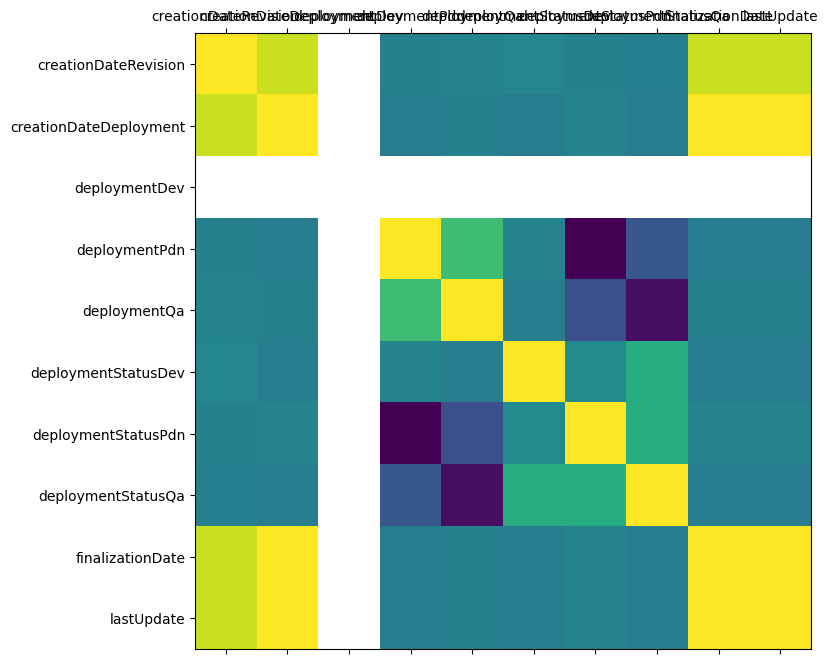

In [92]:
# Representar gráficamente la matriz de correlación
corr = df_no_version.corr()
fig, ax = plt.subplots(figsize=(8, 8))
ax.matshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns);
plt.yticks(range(len(corr.columns)), corr.columns);

C:\Users\dfajardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])
C:\Users\dfajardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
C:\Users\dfajardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
C:\Users\dfajardo\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\plotting\_matplotlib\misc.py:115: RuntimeWarning: invalid value encountered in divide
  adj = (locs - lim1[0]) / (lim

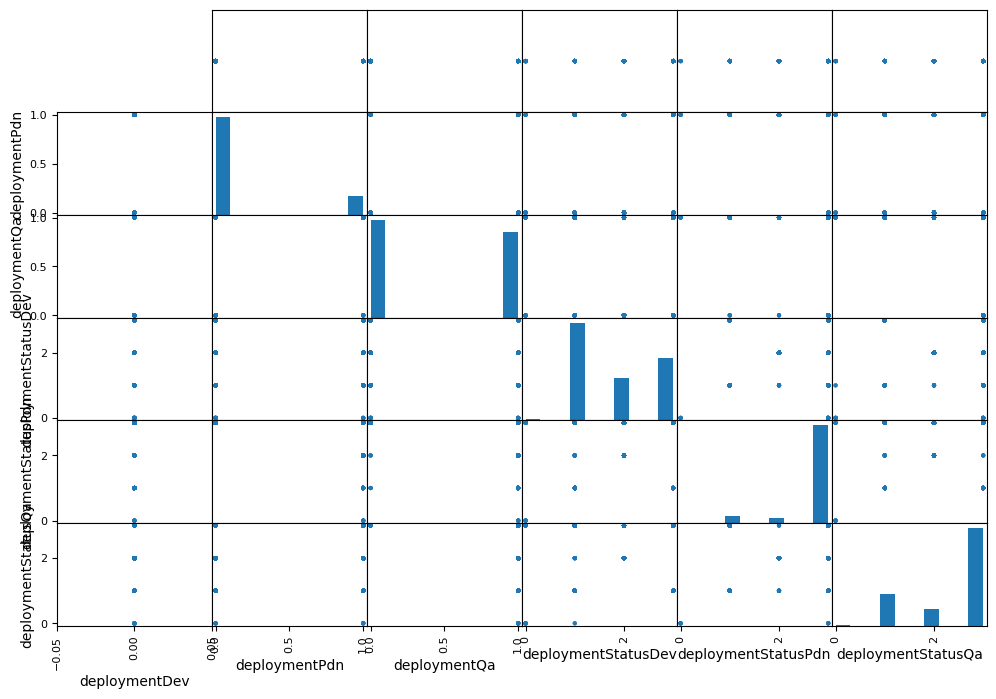

In [93]:
# Representar gráficamente las correlaciones
from pandas.plotting import scatter_matrix

attributes = ["deploymentDev", "deploymentPdn", "deploymentQa", "deploymentStatusDev", "deploymentStatusPdn", "deploymentStatusQa"]

scatter_matrix(df_no_version[attributes], figsize=(12,8))
plt.show()

 #### Entrenamiento del modelo

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Separar variables predictoras (X) y variable objetivo (y)
X = df_no_version.drop(columns=["deploymentStatusDev"])
y = df_no_version["deploymentStatusDev"]

# División del dataset en datos de entrenamiento y prueba (80% - 20%).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalar los datos para mejorar la estabilidad del modelo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar el modelo de regresión logística
reg_log = LogisticRegression(random_state=42, max_iter=100)
reg_log.fit(X_train_scaled, y_train)

# Evaluar la presición del modelo con datos de entrenamiento y prueba
train_score = reg_log.score(X_train_scaled, y_train)
test_score = reg_log.score(X_test_scaled, y_test)

train_score, test_score # Precisión del modelo

(0.6064090480678606, 0.6021100226073851)

### Funciones auxiliares

In [99]:
def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [100]:
# Construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)

In [114]:
def evaluate_result(y_pred, y, y_prep_pred, y_prep, metric):
    print(metric.__name__, "WITHOUT preparation:", metric(y_pred, y, average='weighted'))
    print(metric.__name__, "WITH preparation:", metric(y_prep_pred, y_prep, average='weighted'))

#### División del conjunto de datos

In [101]:
# Dividimos el conjunto de datos
train_set, val_set, test_set = train_val_test_split(df_no_version)

In [102]:
X_train, y_train = remove_labels(train_set, 'deploymentStatusDev')
X_val, y_val = remove_labels(val_set, 'deploymentStatusDev')
X_test, y_test = remove_labels(test_set, 'deploymentStatusDev')

### Escalando el conjunto de datos

In [104]:
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [105]:
X_test_scaled = scaler.transform(X_test)

In [106]:
X_val_scaled = scaler.transform(X_val)

In [108]:
from pandas import DataFrame

# Transformación a un DataFrame de Pandas
X_train_scaled = DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled.head(10)

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate
11499,-0.197063,-0.972912,0.0,0.0,0.0,0.0,0.0,-0.973167,-0.973167
12543,-1.043917,-0.740777,0.0,0.0,0.0,0.0,0.0,-0.740985,-0.740985
9039,1.326814,0.641328,0.0,0.0,0.0,0.0,0.0,0.641023,0.641023
5187,0.353125,0.170785,0.0,0.0,0.0,0.0,0.0,0.170546,0.170546
8087,1.495710,0.722949,0.0,0.0,1.0,0.0,0.0,0.722661,0.722661
847,1.103473,0.533397,0.0,0.0,1.0,0.0,-2.0,0.533104,0.533104
6999,-0.085876,-0.041367,0.0,1.0,1.0,-2.0,-2.0,-0.041507,-0.041507
10728,-1.043986,-0.857009,0.0,0.0,1.0,0.0,0.0,-0.857177,-0.857177
4379,0.256154,0.123922,0.0,0.0,1.0,0.0,-2.0,0.123695,0.123695
6411,1.527707,0.738411,0.0,1.0,1.0,-1.0,-1.0,0.738055,0.738055


In [109]:
X_train_scaled.describe()

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate
count,3979.000000,3979.000000,3979.0,3979.000000,3979.000000,3979.000000,3979.000000,3979.000000,3979.000000
mean,0.218999,-0.084381,0.0,0.165871,0.477758,-0.191003,-0.575019,-0.084556,-0.084554
std,0.709123,0.548285,0.0,0.372011,0.499568,0.551254,0.843506,0.548261,0.548260
min,-1.052215,-2.479752,0.0,0.000000,0.000000,-3.000000,-3.000000,-2.479712,-2.479712
25%,-0.197063,-0.611840,0.0,0.000000,0.000000,0.000000,-1.000000,-0.612087,-0.612087
50%,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.802937,0.388160,0.0,0.000000,1.000000,0.000000,0.000000,0.387913,0.387913
max,1.527769,0.738441,0.0,1.000000,1.000000,0.000000,0.000000,0.738125,0.738125


### Arbol de Decisión

In [110]:
from sklearn.tree import DecisionTreeClassifier

MAX_DEPTH = 20

# Modelo entrenado con el conjunto de datos sin escalar
clf_tree = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [111]:
# Modelo entrenado con el conjunto de datos escalado
clf_tree_scaled = DecisionTreeClassifier(max_depth=MAX_DEPTH, random_state=42)
clf_tree_scaled.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=20, random_state=42)

In [112]:
# Predecimos con el conjunto de datos de entrenamiento
y_train_pred = clf_tree.predict(X_train)
y_train_prep_pred = clf_tree_scaled.predict(X_train_scaled)

In [115]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_train_pred, y_train, y_train_prep_pred, y_train, f1_score)

f1_score WITHOUT preparation: 0.9095251934003921
f1_score WITH preparation: 0.9108001917992745


In [118]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_tree.predict(X_val)
y_prep_pred = clf_tree_scaled.predict(X_val_scaled)

In [119]:
# Comparamos resultados entre escalado y sin escalar
evaluate_result(y_pred, y_val, y_prep_pred, y_val, f1_score)

f1_score WITHOUT preparation: 0.7142853104165938
f1_score WITH preparation: 0.7144804339846409


In [120]:
X_train

,creationDateRevision,creationDateDeployment,deploymentDev,deploymentPdn,deploymentQa,deploymentStatusPdn,deploymentStatusQa,finalizationDate,lastUpdate
11499,1.737994e+09,1.726869e+09,0,0,0,3,3,1.726869e+09,1.726869e+09
12543,1.732807e+09,1.729811e+09,0,0,0,3,3,1.729812e+09,1.729812e+09
9039,1.747328e+09,1.747328e+09,0,0,0,3,3,1.747328e+09,1.747328e+09
5187,1.741364e+09,1.741364e+09,0,0,0,3,3,1.741365e+09,1.741365e+09
8087,1.748362e+09,1.748362e+09,0,0,1,3,3,1.748363e+09,1.748363e+09
...,...,...,...,...,...,...,...,...,...
7611,1.747776e+09,1.747776e+09,0,0,0,3,3,1.747776e+09,1.747776e+09
9986,1.748440e+09,1.748440e+09,0,0,0,3,3,1.748441e+09,1.748441e+09
10023,1.744054e+09,1.744054e+09,0,0,0,3,3,1.744054e+09,1.744054e+09
10587,1.732807e+09,1.726256e+09,0,0,1,3,2,1.726256e+09,1.726256e+09


In [121]:
# Reducimos el número de atributos del conjunto de datos para visualizarlo mejor
X_train_reduced = X_train[['deploymentStatusPdn', 'deploymentStatusQa']]

In [122]:
# Generamos un modelo con el conjunto de datos reducido
clf_tree_reduced = DecisionTreeClassifier(max_depth=2, random_state=42)
clf_tree_reduced.fit(X_train_reduced, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

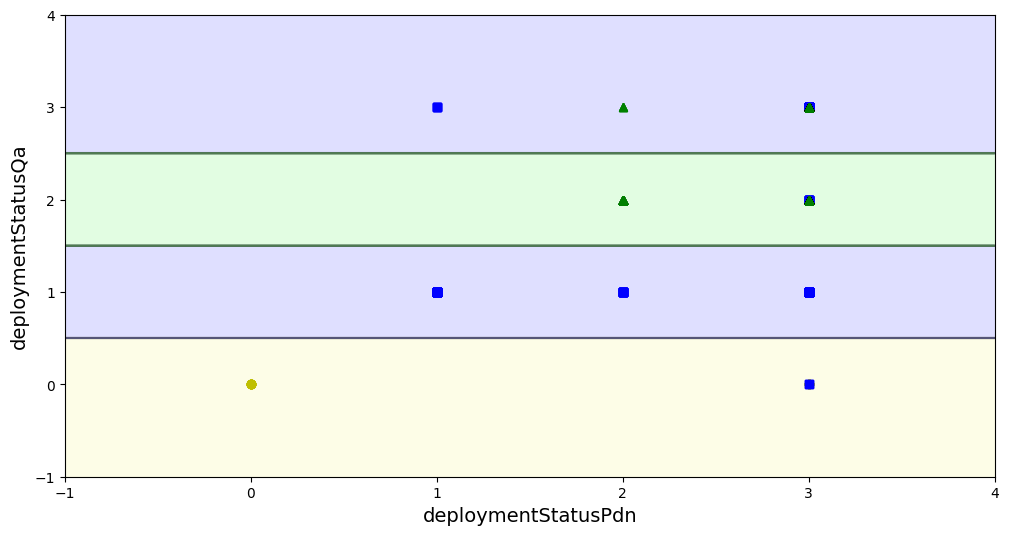

In [124]:
# Representamos gráficamente el límite de decisión construido
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
%matplotlib inline

def plot_decision_boundary(clf, X, y, plot_training=True, resolution=1000):
    mins = X.min(axis=0) - 1
    maxs = X.max(axis=0) + 1
    x1, x2 = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
    plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="DEPLOYED")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="PENDING")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="FAILED")
        plt.axis([mins[0], maxs[0], mins[1], maxs[1]])               
    plt.xlabel('deploymentStatusPdn', fontsize=14)
    plt.ylabel('deploymentStatusQa', fontsize=14, rotation=90)

plt.figure(figsize=(12, 6))
plot_decision_boundary(clf_tree_reduced, X_train_reduced.values, y_train)
plt.show()

In [125]:
# Pintamos el árbol para compararlo con la representación gráfica anterior
from graphviz import Source
from sklearn.tree import export_graphviz
import os

export_graphviz(
        clf_tree_reduced,
        out_file="despliegues.dot",
        feature_names=X_train_reduced.columns,
        class_names=["DEPLOYED", "PENDING", "FAILED"],
        rounded=True,
        filled=True
    )

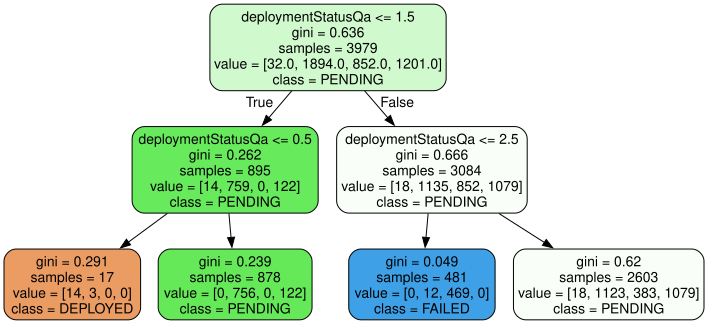

In [126]:
Source.from_file("despliegues.dot")